In [34]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import sys
from datetime import datetime
import argparse
import intake
from easygems import healpix as egh
import healpy as hp

In [26]:
def convert_time(time_array):
    """Convert cftime to standard datetime64"""
    if hasattr(time_array[0], 'year'):
        return np.array([np.datetime64(datetime(t.year, t.month, t.day, t.hour)) 
                         for t in time_array])
    return time_array

In [129]:
def extract_healpix_variable_to_latlon(
    hp_data,
    storm_lon,
    storm_lat,
    storm_time,
    hp_grid,
    nside,
    radius=10.0,
    lon_res=0.25,
    lat_res=0.25,
    x_dimname="lon",
    y_dimname="lat",
    x_coordname="lon",
    y_coordname="lat"
):
    """
    Extract HEALPix variable and remap to regular lat-lon grid centered at storm location.
    
    Parameters
    ----------
    hp_data : xarray.DataArray
        HEALPix variable data with 'cell' and 'time' dimensions
    storm_lon : float
        Storm center longitude
    storm_lat : float
        Storm center latitude
    storm_time : np.datetime64
        Storm time
    hp_grid : xarray.Dataset
        HEALPix grid with 'lat' and 'lon' coordinates
    nside : int
        HEALPix nside parameter
    radius : float, optional
        Radius around storm center in degrees (default: 10.0)
    lon_res : float, optional
        Longitude resolution in degrees (default: 0.25)
    lat_res : float, optional
        Latitude resolution in degrees (default: 0.25)
    x_dimname : str, optional
        Name for longitude dimension (default: "lon")
    y_dimname : str, optional
        Name for latitude dimension (default: "lat")
    x_coordname : str, optional
        Name for longitude coordinate (default: "lon")
    y_coordname : str, optional
        Name for latitude coordinate (default: "lat")
    
    Returns
    -------
    xarray.DataArray
        Variable remapped to regular lat-lon grid
    """
    # Select data at storm time
    data_at_time = hp_data.sel(time=storm_time, method="nearest").compute()
    
    # Find the closest grid points to the storm center
    lon_center = round(storm_lon / lon_res) * lon_res
    lat_center = round(storm_lat / lat_res) * lat_res
    
    # Create a meshgrid around the storm center within radius
    lon_grid = np.arange(lon_center - radius, lon_center + radius + lon_res, lon_res)
    lat_grid = np.arange(lat_center - radius, lat_center + radius + lat_res, lat_res)
    
    # Get HEALPix pixel indices for the grid points
    pix = xr.DataArray(
        hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid), nest=True, lonlat=True),
        coords=((y_dimname, lat_grid), (x_dimname, lon_grid)),
    )
    
    # Drop lat/lon coordinates from input data to avoid conflicts during isel
    data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
    
    # Remap variable to lat/lon grid
    data_gridded = data_dropped.isel(cell=pix)
    
    return data_gridded

In [82]:
catalog_file = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
current_location = "NERSC"

source = "scream_ne120_inst"
catalog_params = {
    "zoom": 8
}

# Read catalog
cat = intake.open_catalog(catalog_file)
if current_location:
    cat = cat[current_location]

print(f"Loading catalog {source}...")
# Load HEALPix dataset
ds = cat[source](**catalog_params).to_dask().pipe(
    egh.attach_coords, signed_lon=True
)
# Convert time coordinates to datetime64 and assign back to dataset
ds = ds.assign_coords(time=convert_time(ds.time.values))

# Get HEALPix grid
print("Computing HEALPix grid...")
hp_grid = ds[['lat', 'lon']].compute()
nside = egh.get_nside(hp_grid)
print(f"Grid: nside={nside}")

Loading catalog scream_ne120_inst...


/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


Computing HEALPix grid...
Grid: nside=256


In [85]:
rh850 = ds["rh850"]
rh850

<xarray.DataArray 'rh850' (time: 3169, cell: 786432)> Size: 10GB
dask.array<open_dataset-rh850, shape=(3169, 786432), dtype=float32, chunksize=(24, 4096), chunktype=numpy.ndarray>
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... -44.82 -45.18 -45.0
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
  * time     (time) datetime64[us] 25kB 2019-08-01 ... 2020-09-01
Attributes:
    long_name:  RelativeHumidity_at_850hPa
    units:      1

In [2]:
root_dir = "/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/"
in_file = f"{root_dir}screamv2_ne120_tracking/screamv2_ne120_hp8.etc_stitched_nodes.txt"
in_file

'/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/screamv2_ne120_tracking/screamv2_ne120_hp8.etc_stitched_nodes.txt'

In [3]:
mcs_dir = "/pscratch/sd/w/wcmca1/hackathon/mcs/scream/stats/"
mcs_trackfile = f"{mcs_dir}/mcs_tracks_final_20190801.0000_20200901.0000.nc"
mcs_trackfile

'/pscratch/sd/w/wcmca1/hackathon/mcs/scream/stats//mcs_tracks_final_20190801.0000_20200901.0000.nc'

In [13]:
# Parse the storm data text file
def parse_storm_file(file_path, unstructured_mesh=True):
    storm_data = []
    with open(file_path, 'r') as f:
        storm_id = 0
        for line in f:
            line = line.strip()
            if line.startswith("start"):
                # New storm
                storm_id += 1
                num_timesteps, year, month, day, hour = map(int, line.split()[1:])
            else:
                # Storm details
                cols = line.split()
                if unstructured_mesh:
                    storm_data.append({
                        "storm_id": storm_id,
                        "grid_id": int(cols[0]),
                        "lon": float(cols[1]),
                        "lat": float(cols[2]),
                        "year": int(cols[-4]),
                        "month": int(cols[-3]),
                        "day": int(cols[-2]),
                        "hour": int(cols[-1]),
                        "base_time": np.datetime64(f"{int(cols[-4]):04d}-{int(cols[-3]):02d}-{int(cols[-2]):02d}T{int(cols[-1]):02d}:00")
                    })
                else:
                    storm_data.append({
                        "storm_id": storm_id,
                        "lon_id": int(cols[0]),
                        "lat_id": int(cols[1]),
                        "lon": float(cols[2]),
                        "lat": float(cols[3]),
                        "year": int(cols[-4]),
                        "month": int(cols[-3]),
                        "day": int(cols[-2]),
                        "hour": int(cols[-1]),
                        "base_time": np.datetime64(f"{int(cols[-4]):04d}-{int(cols[-3]):02d}-{int(cols[-2]):02d}T{int(cols[-1]):02d}:00")
                    })
    return pd.DataFrame(storm_data)

In [14]:
unstructured_mesh = True
storm_df = parse_storm_file(in_file, unstructured_mesh=unstructured_mesh)
storm_df

,storm_id,grid_id,lon,lat,year,month,day,hour,base_time
0,1,225172,328.349301,51.062119,2019,8,1,0,2019-08-01 00:00:00
1,1,225144,330.365876,51.836503,2019,8,1,6,2019-08-01 06:00:00
2,1,227884,332.185954,52.994706,2019,8,1,12,2019-08-01 12:00:00
3,1,227986,332.396932,53.956885,2019,8,1,18,2019-08-01 18:00:00
4,1,249882,330.896761,55.873462,2019,8,2,0,2019-08-02 00:00:00
...,...,...,...,...,...,...,...,...,...
18699,1329,663199,237.147256,-59.867208,2020,8,30,18,2020-08-30 18:00:00
18700,1329,662752,243.120830,-62.508739,2020,8,31,0,2020-08-31 00:00:00
18701,1329,661227,249.306602,-64.761070,2020,8,31,6,2020-08-31 06:00:00
18702,1329,661044,255.000040,-67.376398,2020,8,31,12,2020-08-31 12:00:00


In [39]:
# ETC 1014: north Pacific, 2020-05-18 18Z - 2020-05-24 18Z
# 3-way overlap period: 2020-05-15 18Z - 2020-05-22 12Z

# np.where(storm_df['storm_id'] == 1014)

# Extract storm 1014 data
storm_1014 = storm_df.loc[storm_df['storm_id'] == 1014]
storm_1014

,storm_id,grid_id,lon,lat,year,month,day,hour,base_time
14270,1014,167911,202.148438,40.424109,2020,5,20,18,2020-05-20 18:00:00
14271,1014,170650,204.061587,41.810446,2020,5,21,0,2020-05-21 00:00:00
14272,1014,170706,205.379970,43.008680,2020,5,21,6,2020-05-21 06:00:00
14273,1014,170812,207.222196,44.399883,2020,5,21,12,2020-05-21 12:00:00
14274,1014,171619,209.799978,47.945558,2020,5,21,18,2020-05-21 18:00:00
14275,1014,171909,210.353753,50.480121,2020,5,22,0,2020-05-22 00:00:00
14276,1014,171982,210.519781,52.416100,2020,5,22,6,2020-05-22 06:00:00
14277,1014,172027,209.769209,53.764658,2020,5,22,12,2020-05-22 12:00:00
14278,1014,177491,209.145055,54.149000,2020,5,22,18,2020-05-22 18:00:00
14279,1014,177495,209.450240,54.532924,2020,5,23,0,2020-05-23 00:00:00


In [ ]:
# Load MCS stats file as a reference for the Pandas DataFrame structure
# used in Laura's MCS environment extraction code: get_env_vars.py
mcs_trackstats = xr.open_dataset(mcs_trackfile)

# ONLY load essential variables
required_vars = ['meanlon', 'meanlat', 'base_time']
subset = mcs_trackstats[required_vars].compute()
df_all = subset.to_dataframe().reset_index()
df_all
# print(f"Loaded {len(df_all)} total track-time points")

# # Filter by tracks from land fraction file if provided
# if tracks_to_process is not None:
#     df_all = df_all[df_all['tracks'].isin(tracks_to_process)]
#     print(f"Filtered to {len(df_all)} track-time points from land fraction file")

,tracks,times,meanlon,meanlat,base_time
0,0,0,-146.117874,-40.489239,2019-08-01 01:00:00
1,0,1,-148.803543,-43.098492,2019-08-01 02:00:00
2,0,2,-148.724335,-43.480473,2019-08-01 03:00:00
3,0,3,-149.336044,-44.175705,2019-08-01 04:00:00
4,0,4,-150.073959,-44.962494,2019-08-01 05:00:00
...,...,...,...,...,...
36716545,56486,645,NaN,NaN,NaT
36716546,56486,646,NaN,NaN,NaT
36716547,56486,647,NaN,NaN,NaT
36716548,56486,648,NaN,NaN,NaT


In [38]:
# df_all['base_time']
df_all.loc[df_all['tracks'] == 41381]

,tracks,times,meanlon,meanlat,base_time
26897650,41381,0,167.848969,36.656616,2020-05-20 17:00:00
26897651,41381,1,168.596359,36.219570,2020-05-20 18:00:00
26897652,41381,2,168.829102,36.252289,2020-05-20 19:00:00
26897653,41381,3,169.642929,36.217304,2020-05-20 20:00:00
26897654,41381,4,170.502243,36.226883,2020-05-20 21:00:00
...,...,...,...,...,...
26898295,41381,645,NaN,NaN,NaT
26898296,41381,646,NaN,NaN,NaT
26898297,41381,647,NaN,NaN,NaT
26898298,41381,648,NaN,NaN,NaT


In [ ]:
storm_1014['base_time']

14270   2020-05-20 18:00:00
14271   2020-05-21 00:00:00
14272   2020-05-21 06:00:00
14273   2020-05-21 12:00:00
14274   2020-05-21 18:00:00
14275   2020-05-22 00:00:00
14276   2020-05-22 06:00:00
14277   2020-05-22 12:00:00
14278   2020-05-22 18:00:00
14279   2020-05-23 00:00:00
14280   2020-05-23 06:00:00
14281   2020-05-23 12:00:00
14282   2020-05-23 18:00:00
14283   2020-05-24 00:00:00
14284   2020-05-24 06:00:00
14285   2020-05-24 12:00:00
14286   2020-05-24 18:00:00
Name: base_time, dtype: datetime64[ns]

In [47]:
# storm_1014['lon'], storm_1014['lat']
storm_1014['lon']

14270    202.148438
14271    204.061587
14272    205.379970
14273    207.222196
14274    209.799978
14275    210.353753
14276    210.519781
14277    209.769209
14278    209.145055
14279    209.450240
14280    210.398916
14281    211.059763
14282    210.937481
14283    209.914752
14284    209.916180
14285    210.906574
14286    212.213097
Name: lon, dtype: float64

In [89]:
row = 14270
_grid_id = storm_1014.loc[row]['grid_id']
_lon = storm_1014.loc[row]['lon']
_lat = storm_1014.loc[row]['lat']
_base_time = storm_1014.loc[row]['base_time']

_grid_id, _lon, _lat, _base_time

(np.int64(167911),
 np.float64(202.148438),
 np.float64(40.424109),
 Timestamp('2020-05-20 18:00:00'))

In [92]:
# Get HEALPix pixel index for the storm location
# Check if this is equal to _grid_id
if hp.ang2pix(nside, _lon, _lat, nest=True, lonlat=True) == _grid_id:
    print(f"Grid ID matches HEALPix pixel index: {_grid_id}")

Grid ID matches HEALPix pixel index: 167911


In [109]:
# Get HEALPix pixel data for the storm location
ihp_pix = hp_grid.sel(cell=_grid_id)
# Convert to standard lon (0-360)
_lon360_hp = ihp_pix.lon.item() % 360
_lon_hp = ihp_pix.lon.item()
_lat_hp = ihp_pix.lat.item()
ihp_pix

<xarray.Dataset> Size: 32B
Dimensions:  ()
Coordinates:
    lat      float64 8B 40.42
    lon      float64 8B -157.9
    crs      int64 8B 0
    cell     int64 8B 167911
Data variables:
    *empty*
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          3
    averaging_frequency_units:    nhours
    averaging_type:               INSTANT
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [110]:
_lon_hp, _lat_hp

(-157.8515625, 40.42389940146197)

In [ ]:
# # Get HEALPix pixels within a circular area around the storm location
# # This is not necessary if we're remapping the HEALPix data to a lat-lon grid
# nest = True
# RADIUS = 10.0  # degrees

# area_pixels = hp.query_disc(
#     nside, 
#     hp.pix2vec(nside, _grid_id, nest=nest), 
#     np.radians(RADIUS),
#     inclusive=False, 
#     nest=nest
# )
# area_pixels

array([165503, 165551, 165557, ..., 177283, 177284, 177288])

In [119]:
# Select variables for the storm area at the storm time
# _rh850 = rh850.sel(cell=area_pixels).sel(time=_base_time, method="nearest").compute()
_rh850 = rh850.sel(time=_base_time, method="nearest").compute()
_rh850

<xarray.DataArray 'rh850' (cell: 786432)> Size: 3MB
array([0.6697594 , 0.73038465, 0.7188791 , ..., 0.53904295, 0.5728518 ,
       0.49596855], dtype=float32)
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... -44.82 -45.18 -45.0
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    time     datetime64[us] 8B 2020-05-20T18:00:00
Attributes:
    long_name:  RelativeHumidity_at_850hPa
    units:      1

In [ ]:
# Make a regular lat-lon grid center at the storm location
RADIUS = 10.0  # degrees
lon_res = 0.25
lat_res = 0.25
x_dimname = "lon"
y_dimname = "lat"
x_coordname = "lon"
y_coordname = "lat"
# Find the closest 0.25 deg grid points to the storm center
lon_center = round(_lon_hp / lon_res) * lon_res
lat_center = round(_lat_hp / lat_res) * lat_res
# Create a meshgrid around the storm center within a RADIUS
lon_grid = np.arange(lon_center - RADIUS, lon_center + RADIUS + lon_res, lon_res)
lat_grid = np.arange(lat_center - RADIUS, lat_center + RADIUS + lat_res, lat_res)
# Get HEALPix pixel indices for the grid points
pix = xr.DataArray(
    hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid), nest=True, lonlat=True),
    coords=((y_dimname, lat_grid), (x_dimname, lon_grid)),
)

# Drop lat/lon coordinates from input_data to avoid conflicts during isel
_rh850_dropped = _rh850.drop_vars([y_coordname, x_coordname], errors='ignore')
# Remap variable to lat/lon grid
_rh850_gridded = _rh850_dropped.isel(cell=pix)
_rh850_gridded

<xarray.DataArray 'rh850' (lat: 81, lon: 81)> Size: 26kB
array([[0.40702042, 0.6716717 , 0.6716717 , ..., 0.53941286, 0.5965822 ,
        0.5711959 ],
       [0.43551227, 0.25371343, 0.5854058 , ..., 0.5942113 , 0.6229844 ,
        0.600091  ],
       [0.7221367 , 0.4830561 , 0.21758398, ..., 0.65512323, 0.6229844 ,
        0.6230686 ],
       ...,
       [0.9971106 , 1.0021881 , 1.001766  , ..., 1.0027963 , 1.0051701 ,
        0.9965908 ],
       [1.0021881 , 0.9887959 , 1.0014632 , ..., 0.9895866 , 0.9895866 ,
        0.9611496 ],
       [0.9525951 , 0.97666794, 0.99979234, ..., 0.931837  , 0.95734304,
        0.88166314]], dtype=float32)
Coordinates:
    crs      int64 8B 0
    cell     (lat, lon) int64 52kB 166584 166579 166579 ... 171830 171829 171872
    time     datetime64[us] 8B 2020-05-20T18:00:00
  * lat      (lat) float64 648B 30.5 30.75 31.0 31.25 ... 49.75 50.0 50.25 50.5
  * lon      (lon) float64 648B -167.8 -167.5 -167.2 ... -148.2 -148.0 -147.8
Attributes:
    long_name:  RelativeHumidity_at_850hPa
    units:      1

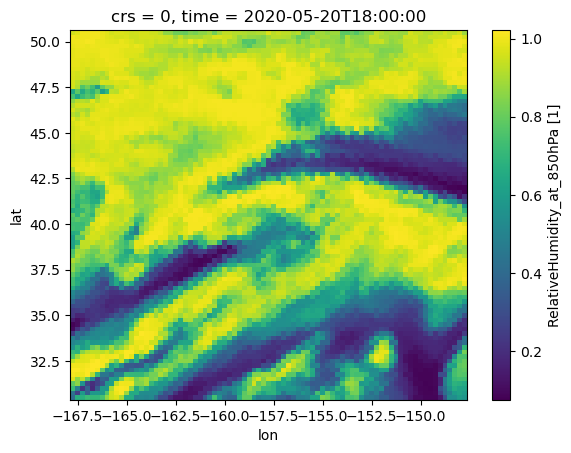

In [127]:
_rh850_gridded.plot()

In [130]:
# Test the function with the same storm data
rh850_gridded_func = extract_healpix_variable_to_latlon(
    hp_data=rh850,
    storm_lon=_lon_hp,
    storm_lat=_lat_hp,
    storm_time=_base_time,
    hp_grid=hp_grid,
    nside=nside,
    radius=10.0,
    lon_res=0.25,
    lat_res=0.25
)
rh850_gridded_func

<xarray.DataArray 'rh850' (lat: 81, lon: 81)> Size: 26kB
array([[0.40702042, 0.6716717 , 0.6716717 , ..., 0.53941286, 0.5965822 ,
        0.5711959 ],
       [0.43551227, 0.25371343, 0.5854058 , ..., 0.5942113 , 0.6229844 ,
        0.600091  ],
       [0.7221367 , 0.4830561 , 0.21758398, ..., 0.65512323, 0.6229844 ,
        0.6230686 ],
       ...,
       [0.9971106 , 1.0021881 , 1.001766  , ..., 1.0027963 , 1.0051701 ,
        0.9965908 ],
       [1.0021881 , 0.9887959 , 1.0014632 , ..., 0.9895866 , 0.9895866 ,
        0.9611496 ],
       [0.9525951 , 0.97666794, 0.99979234, ..., 0.931837  , 0.95734304,
        0.88166314]], dtype=float32)
Coordinates:
    crs      int64 8B 0
    cell     (lat, lon) int64 52kB 166584 166579 166579 ... 171830 171829 171872
    time     datetime64[us] 8B 2020-05-20T18:00:00
  * lat      (lat) float64 648B 30.5 30.75 31.0 31.25 ... 49.75 50.0 50.25 50.5
  * lon      (lon) float64 648B -167.8 -167.5 -167.2 ... -148.2 -148.0 -147.8
Attributes:
    long_name:  RelativeHumidity_at_850hPa
    units:      1

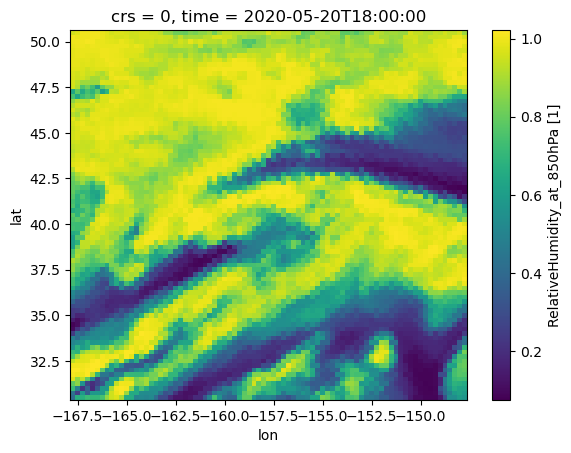

In [131]:
rh850_gridded_func.plot()

## Testing boundary conditions for lat-lon grid extraction

Let's test edge cases to see if we need to handle out-of-bound lat-lon points.

In [132]:
# Test Case 1: Storm near North Pole
test_lat_north = 85.0  # Near North Pole
test_lon_north = 0.0
radius = 10.0
lon_res = 0.25
lat_res = 0.25

lon_center = round(test_lon_north / lon_res) * lon_res
lat_center = round(test_lat_north / lat_res) * lat_res

# Create lat-lon grid
lon_grid = np.arange(lon_center - radius, lon_center + radius + lon_res, lon_res)
lat_grid = np.arange(lat_center - radius, lat_center + radius + lat_res, lat_res)

print(f"Storm center: lat={lat_center}, lon={lon_center}")
print(f"Latitude range: {lat_grid.min()} to {lat_grid.max()}")
print(f"Longitude range: {lon_grid.min()} to {lon_grid.max()}")
print(f"Any |lat| > 90? {np.any(np.abs(lat_grid) > 90)}")
print(f"Any |lon| > 180? {np.any(np.abs(lon_grid) > 180)}")

Storm center: lat=85.0, lon=0.0
Latitude range: 75.0 to 95.0
Longitude range: -10.0 to 10.0
Any |lat| > 90? True
Any |lon| > 180? False


In [133]:
# Test Case 2: Storm near International Date Line
test_lat_dateline = 45.0
test_lon_dateline = 178.0  # Near +180
radius = 10.0

lon_center = round(test_lon_dateline / lon_res) * lon_res
lat_center = round(test_lat_dateline / lat_res) * lat_res

# Create lat-lon grid
lon_grid = np.arange(lon_center - radius, lon_center + radius + lon_res, lon_res)
lat_grid = np.arange(lat_center - radius, lat_center + radius + lat_res, lat_res)

print(f"\nStorm center: lat={lat_center}, lon={lon_center}")
print(f"Latitude range: {lat_grid.min()} to {lat_grid.max()}")
print(f"Longitude range: {lon_grid.min()} to {lon_grid.max()}")
print(f"Any |lat| > 90? {np.any(np.abs(lat_grid) > 90)}")
print(f"Any lon > 180? {np.any(lon_grid > 180)}")


Storm center: lat=45.0, lon=178.0
Latitude range: 35.0 to 55.0
Longitude range: 168.0 to 188.0
Any |lat| > 90? False
Any lon > 180? True


In [134]:
# Test what happens when we pass out-of-bound coordinates to hp.ang2pix
# HEALPix should handle this gracefully or error out

# Test with lat > 90
test_coords = [
    (95.0, 0.0, "lat > 90"),
    (-95.0, 0.0, "lat < -90"),
    (45.0, 185.0, "lon > 180"),
    (45.0, -185.0, "lon < -180"),
]

for lat, lon, description in test_coords:
    try:
        pix_idx = hp.ang2pix(nside, lon, lat, nest=True, lonlat=True)
        print(f"{description}: lat={lat}, lon={lon} -> pixel={pix_idx} ✓")
    except Exception as e:
        print(f"{description}: lat={lat}, lon={lon} -> ERROR: {e}")

lat > 90: lat=95.0, lon=0.0 -> ERROR: THETA is out of range [0,pi]
lat < -90: lat=-95.0, lon=0.0 -> ERROR: THETA is out of range [0,pi]
lon > 180: lat=45.0, lon=185.0 -> pixel=174937 ✓
lon < -180: lat=45.0, lon=-185.0 -> pixel=87974 ✓


### Key Differences: HEALPix vs Regular Grid Extraction

**Your WRF workflow (structured grid):**
- Data is on a **fixed, finite rectangular grid** (ny_d × nx_d)
- Extracting beyond domain boundaries requires padding with NaN
- `pad_array2d()` ensures output is always the requested size (2*ny+1 × 2*nx+1)

**Our HEALPix workflow (global unstructured grid):**
- HEALPix covers the **entire globe** - no boundaries!
- Every valid lat/lon point maps to a valid HEALPix pixel
- `hp.ang2pix()` handles coordinate wrapping automatically:
  - Longitude: wraps around (e.g., 185° → -175°)
  - Latitude: clamped/wrapped at poles (implementation-dependent)

**Do we need padding?**
- **For most cases: NO** - HEALPix is global
- **Exception: Polar regions** - if radius extends beyond pole (|lat| > 90), the lat-lon grid becomes physically invalid. However:
  - `hp.ang2pix()` will handle this (may clamp to pole or wrap)
  - For atmospheric/ocean phenomena, storms typically don't require large radius boxes at extreme polar latitudes
  - If needed, we could add boundary checking/clipping

In [135]:
def extract_healpix_variable_to_latlon_safe(
    hp_data,
    storm_lon,
    storm_lat,
    storm_time,
    hp_grid,
    nside,
    radius=10.0,
    lon_res=0.25,
    lat_res=0.25,
    x_dimname="lon",
    y_dimname="lat",
    x_coordname="lon",
    y_coordname="lat",
    pad_invalid_latitudes=True
):
    """
    Extract HEALPix variable and remap to regular lat-lon grid centered at storm location.
    Pads output with NaN for grids with invalid latitudes beyond poles.
    
    Parameters
    ----------
    hp_data : xarray.DataArray
        HEALPix variable data with 'cell' and 'time' dimensions
    storm_lon : float
        Storm center longitude
    storm_lat : float
        Storm center latitude
    storm_time : np.datetime64
        Storm time
    hp_grid : xarray.Dataset
        HEALPix grid with 'lat' and 'lon' coordinates
    nside : int
        HEALPix nside parameter
    radius : float, optional
        Radius around storm center in degrees (default: 10.0)
    lon_res : float, optional
        Longitude resolution in degrees (default: 0.25)
    lat_res : float, optional
        Latitude resolution in degrees (default: 0.25)
    x_dimname : str, optional
        Name for longitude dimension (default: "lon")
    y_dimname : str, optional
        Name for latitude dimension (default: "lat")
    x_coordname : str, optional
        Name for longitude coordinate (default: "lon")
    y_coordname : str, optional
        Name for latitude coordinate (default: "lat")
    pad_invalid_latitudes : bool, optional
        If True, pad with NaN for invalid latitudes beyond ±90° (default: True)
    
    Returns
    -------
    xarray.DataArray
        Variable remapped to regular lat-lon grid, padded with NaN if needed
    """
    # Select data at storm time
    data_at_time = hp_data.sel(time=storm_time, method="nearest").compute()
    
    # Find the closest grid points to the storm center
    lon_center = round(storm_lon / lon_res) * lon_res
    lat_center = round(storm_lat / lat_res) * lat_res
    
    # Create the FULL lat-lon grid (including invalid latitudes)
    lon_grid_full = np.arange(lon_center - radius, lon_center + radius + lon_res, lon_res)
    lat_grid_full = np.arange(lat_center - radius, lat_center + radius + lat_res, lat_res)
    
    if pad_invalid_latitudes:
        # Identify valid latitude indices (within [-90, 90])
        valid_lat_mask = (lat_grid_full >= -90.0) & (lat_grid_full <= 90.0)
        
        # If all latitudes are valid, proceed normally
        if np.all(valid_lat_mask):
            lon_grid = lon_grid_full
            lat_grid = lat_grid_full
            
            # Get HEALPix pixel indices for the grid points
            pix = xr.DataArray(
                hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid), nest=True, lonlat=True),
                coords=((y_dimname, lat_grid), (x_dimname, lon_grid)),
            )
            
            # Drop lat/lon coordinates from input data to avoid conflicts during isel
            data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
            
            # Remap variable to lat/lon grid
            data_gridded = data_dropped.isel(cell=pix)
            
        else:
            # Some latitudes are invalid - need to pad with NaN
            # Extract only valid latitudes
            lat_grid_valid = lat_grid_full[valid_lat_mask]
            lon_grid = lon_grid_full
            
            # Get HEALPix pixel indices for VALID grid points only
            pix_valid = xr.DataArray(
                hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid_valid), nest=True, lonlat=True),
                coords=((y_dimname, lat_grid_valid), (x_dimname, lon_grid)),
            )
            
            # Drop lat/lon coordinates from input data to avoid conflicts during isel
            data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
            
            # Remap variable to lat/lon grid for valid points
            data_valid = data_dropped.isel(cell=pix_valid)
            
            # Create full output array with NaN padding
            ny_full = len(lat_grid_full)
            nx_full = len(lon_grid)
            
            # Initialize full array with NaN
            full_shape = (ny_full, nx_full)
            data_full = np.full(full_shape, np.nan, dtype=data_valid.dtype)
            
            # Find indices where to place valid data
            valid_lat_indices = np.where(valid_lat_mask)[0]
            
            # Fill in the valid data
            for i, lat_idx in enumerate(valid_lat_indices):
                data_full[lat_idx, :] = data_valid.values[i, :]
            
            # Create output DataArray with full grid
            data_gridded = xr.DataArray(
                data_full,
                coords={
                    y_dimname: lat_grid_full,
                    x_dimname: lon_grid
                },
                dims=[y_dimname, x_dimname],
                attrs=data_valid.attrs
            )
    else:
        # No padding - clip to valid latitudes only
        lat_min = max(lat_center - radius, -90.0)
        lat_max = min(lat_center + radius, 90.0)
        
        lon_grid = lon_grid_full
        lat_grid = np.arange(lat_min, lat_max + lat_res, lat_res)
        
        # Get HEALPix pixel indices for the grid points
        pix = xr.DataArray(
            hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid), nest=True, lonlat=True),
            coords=((y_dimname, lat_grid), (x_dimname, lon_grid)),
        )
        
        # Drop lat/lon coordinates from input data to avoid conflicts during isel
        data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
        
        # Remap variable to lat/lon grid
        data_gridded = data_dropped.isel(cell=pix)
    
    return data_gridded

### Summary: Do we need padding like `pad_array2d()`?

**Short answer: Usually NO, but it depends on your requirements.**

**Reasons why HEALPix is different:**
1. **Global coverage**: HEALPix covers the entire sphere - no domain boundaries
2. **Automatic wrapping**: `hp.ang2pix()` handles longitude wrapping (e.g., 185° works fine)
3. **Output size always matches**: Unlike regional grids, you always get the full requested lat-lon box (unless you clip at poles)

**When you might want boundary handling:**
1. **Polar regions with large radius**: If storm is at 85°N with 10° radius, lat_max = 95°N (invalid)
   - Solution: Use `clip_latitudes=True` in the enhanced function above
   - This will clip lat_grid to [-90, 90], so output may be asymmetric
2. **Consistent output dimensions**: If you need all outputs to be exactly (2*ny+1 × 2*nx+1) for stacking/concatenation
   - Could pad the output after extraction if needed
   - Less common for HEALPix workflows

**Recommendation:**
- Use the original `extract_healpix_variable_to_latlon()` for most cases
- Use `extract_healpix_variable_to_latlon_safe()` if you're extracting near poles (|lat| > 80°) with large radius
- Run the test cells above to verify `hp.ang2pix()` behavior for your specific cases

## Test padding for storms near poles

In [136]:
# Find a storm near the pole from storm_df to test with real data
# Check latitude distribution
print("Storm latitude statistics:")
print(storm_df['lat'].describe())
print(f"\nMax latitude: {storm_df['lat'].max()}")
print(f"Min latitude: {storm_df['lat'].min()}")

# Find storms with |lat| > 70
polar_storms = storm_df[np.abs(storm_df['lat']) > 70]
print(f"\nNumber of storm points with |lat| > 70: {len(polar_storms)}")
if len(polar_storms) > 0:
    print(polar_storms[['storm_id', 'lat', 'lon', 'base_time']].head(10))

Storm latitude statistics:
count    18704.000000
mean         4.262240
std         56.629767
min        -89.092845
25%        -56.255585
50%         35.685504
75%         55.873512
max         89.465789
Name: lat, dtype: float64

Max latitude: 89.465789
Min latitude: -89.092845

Number of storm points with |lat| > 70: 2542
    storm_id        lat         lon           base_time
48         4 -73.681308  162.303406 2019-08-01 00:00:00
51         4 -73.496747  189.499954 2019-08-02 06:00:00
52         4 -75.156909  198.333299 2019-08-02 12:00:00
53         4 -77.365644  226.304350 2019-08-03 00:00:00
54         4 -76.261873  234.600012 2019-08-03 06:00:00
55         4 -72.572772  243.000023 2019-08-03 12:00:00
56         4 -72.202976  251.907252 2019-08-03 18:00:00
57         4 -72.202990  253.762924 2019-08-04 00:00:00
80         5 -73.681308  162.303406 2019-08-05 18:00:00
81         5 -73.681308  162.303406 2019-08-06 00:00:00


In [137]:
# Test with a simulated storm at high latitude
# Simulate storm at 85°N to test padding behavior
test_storm_lat = 85.0
test_storm_lon = 0.0
test_storm_time = _base_time  # Use same time as before for simplicity

# Calculate expected grid dimensions
test_radius = 10.0
test_lat_min = test_storm_lat - test_radius  # 75°N
test_lat_max = test_storm_lat + test_radius  # 95°N (INVALID!)

print(f"Test storm location: {test_storm_lat}°N, {test_storm_lon}°E")
print(f"Expected lat range: {test_lat_min}° to {test_lat_max}°")
print(f"Latitude exceeds 90°: {test_lat_max > 90}")
print(f"Number of invalid lat points: {int((test_lat_max - 90) / lat_res)}")

Test storm location: 85.0°N, 0.0°E
Expected lat range: 75.0° to 95.0°
Latitude exceeds 90°: True
Number of invalid lat points: 20


In [138]:
# Extract data with padding enabled
rh850_polar_padded = extract_healpix_variable_to_latlon_safe(
    hp_data=rh850,
    storm_lon=test_storm_lon,
    storm_lat=test_storm_lat,
    storm_time=test_storm_time,
    hp_grid=hp_grid,
    nside=nside,
    radius=test_radius,
    lon_res=0.25,
    lat_res=0.25,
    pad_invalid_latitudes=True  # Enable padding
)

print(f"Output shape: {rh850_polar_padded.shape}")
print(f"Latitude range: {rh850_polar_padded.lat.min().values} to {rh850_polar_padded.lat.max().values}")
print(f"Expected shape: ({int(2*test_radius/lat_res + 1)}, {int(2*test_radius/lon_res + 1)})")

# Check for NaN values
n_nan = np.isnan(rh850_polar_padded.values).sum()
n_total = rh850_polar_padded.size
print(f"\nNaN values: {n_nan} / {n_total} ({100*n_nan/n_total:.1f}%)")

rh850_polar_padded

Output shape: (81, 81)
Latitude range: 75.0 to 95.0
Expected shape: (81, 81)

NaN values: 1701 / 6561 (25.9%)


<xarray.DataArray (lat: 81, lon: 81)> Size: 26kB
array([[0.5350223 , 0.42984313, 0.5019612 , ..., 0.4531157 , 0.4910147 ,
        0.49808413],
       [0.36910674, 0.36910674, 0.36910674, ..., 0.5509302 , 0.5509302 ,
        0.5509302 ],
       [0.36196974, 0.36196974, 0.36196974, ..., 0.621242  , 0.621242  ,
        0.621242  ],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)
Coordinates:
  * lat      (lat) float64 648B 75.0 75.25 75.5 75.75 ... 94.25 94.5 94.75 95.0
  * lon      (lon) float64 648B -10.0 -9.75 -9.5 -9.25 ... 9.25 9.5 9.75 10.0
Attributes:
    long_name:  RelativeHumidity_at_850hPa
    units:      1

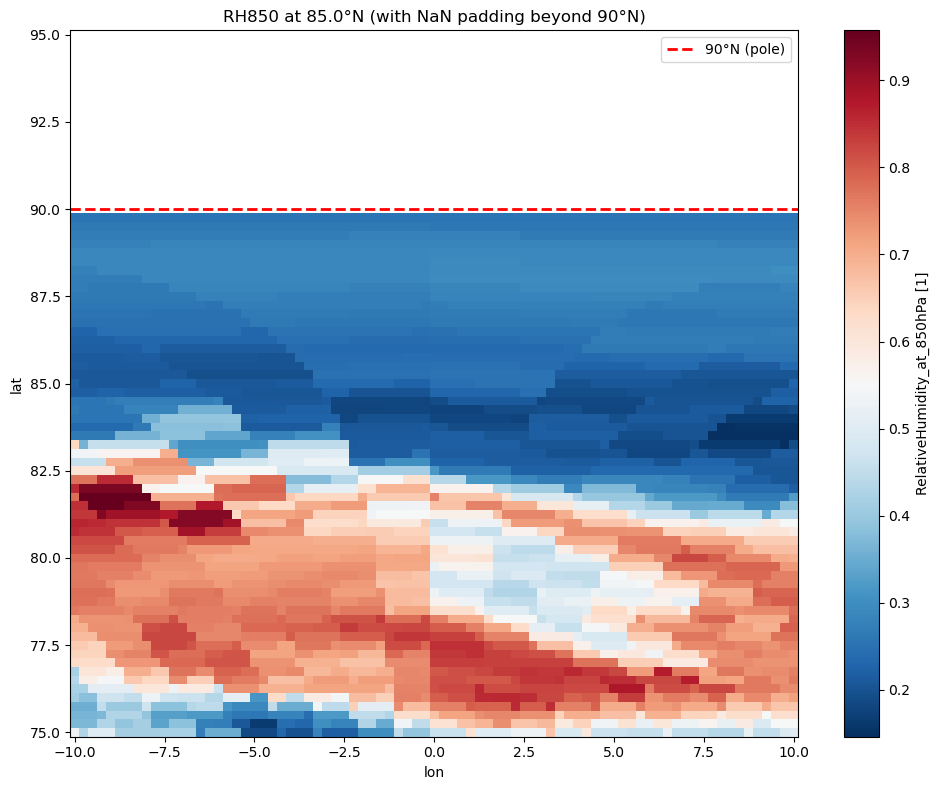

In [139]:
# Visualize the padded data
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
rh850_polar_padded.plot(ax=ax, cmap='RdBu_r')
ax.set_title(f'RH850 at {test_storm_lat}°N (with NaN padding beyond 90°N)')
ax.axhline(y=90, color='red', linestyle='--', linewidth=2, label='90°N (pole)')
ax.legend()
plt.tight_layout()

In [140]:
# Compare: Extract without padding (clipped)
rh850_polar_clipped = extract_healpix_variable_to_latlon_safe(
    hp_data=rh850,
    storm_lon=test_storm_lon,
    storm_lat=test_storm_lat,
    storm_time=test_storm_time,
    hp_grid=hp_grid,
    nside=nside,
    radius=test_radius,
    lon_res=0.25,
    lat_res=0.25,
    pad_invalid_latitudes=False  # Disable padding - clip instead
)

print(f"Clipped output shape: {rh850_polar_clipped.shape}")
print(f"Latitude range: {rh850_polar_clipped.lat.min().values} to {rh850_polar_clipped.lat.max().values}")
print(f"Note: Shape is smaller because invalid latitudes were removed")

rh850_polar_clipped

Clipped output shape: (61, 81)
Latitude range: 75.0 to 90.0
Note: Shape is smaller because invalid latitudes were removed


<xarray.DataArray 'rh850' (lat: 61, lon: 81)> Size: 20kB
array([[0.5350223 , 0.42984313, 0.5019612 , ..., 0.4531157 , 0.4910147 ,
        0.49808413],
       [0.36910674, 0.36910674, 0.36910674, ..., 0.5509302 , 0.5509302 ,
        0.5509302 ],
       [0.36196974, 0.36196974, 0.36196974, ..., 0.621242  , 0.621242  ,
        0.621242  ],
       ...,
       [0.26057947, 0.26057947, 0.26057947, ..., 0.25731492, 0.25731492,
        0.25731492],
       [0.25423038, 0.25423038, 0.25423038, ..., 0.25513113, 0.25513113,
        0.25513113],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)
Coordinates:
    crs      int64 8B 0
    cell     (lat, lon) int64 40kB 253758 253759 253757 ... 65535 65535 65535
    time     datetime64[us] 8B 2020-05-20T18:00:00
  * lat      (lat) float64 488B 75.0 75.25 75.5 75.75 ... 89.25 89.5 89.75 90.0
  * lon      (lon) float64 648B -10.0 -9.75 -9.5 -9.25 ... 9.25 9.5 9.75 10.0
Attributes:
    long_name:  RelativeHumidity_at_850hPa
    units:      1

### Solution for ETC storms near poles

The updated `extract_healpix_variable_to_latlon_safe()` function now handles polar boundary cases similar to your `pad_array2d()` approach:

**Key Features:**
1. **`pad_invalid_latitudes=True` (default)**: Maintains consistent output shape
   - Creates full lat-lon grid including invalid latitudes (e.g., 95°N)
   - Extracts HEALPix data only for valid latitudes (≤90°)
   - Pads invalid latitude rows with NaN
   - Output shape is always `(2*radius/lat_res + 1, 2*radius/lon_res + 1)`

2. **`pad_invalid_latitudes=False`**: Clips to valid range
   - Only creates grid for valid latitudes
   - Output shape may be smaller (asymmetric)
   - No NaN padding needed

**Use Cases:**
- **For stacking/concatenation**: Use `pad_invalid_latitudes=True` to ensure all outputs have the same shape
- **For memory efficiency**: Use `pad_invalid_latitudes=False` if you don't need consistent dimensions
- **For ETC analysis**: Recommended to use `pad_invalid_latitudes=True` since polar ETCs are common

This approach is analogous to your WRF workflow's `pad_array2d()` but adapted for global HEALPix data!

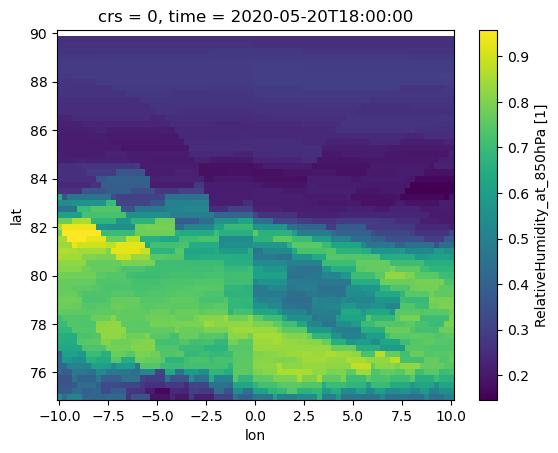

In [141]:
rh850_polar_clipped.plot()